# BPT DIAGRAMS

## Dependencies

In [1]:
%matplotlib widget
from astropy.io import fits
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table, QTable
import numpy as np
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import uncertainties.unumpy as upy


In [2]:
magE_2024_flux = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/magE2024_lines_ratio1_parts.csv')
magE_2024 = magE_2024_flux
magE_2024

,Unnamed: 0,Source,mass,z_red,z_blue,12_log_OH,12_log_OH_ERR,12_log_NH,12_log_NH_ERR,log_NO,...,R,R_ERR,Ne3,Ne3_ERR,RO2NE3,RO2NE3_ERR,AR3,AR3_ERR,AR3O3,AR3O3_ERR
0,0,J0023-0948,8.90,0.053081,0.053060,8.158786,0.010183,6.115521,0.016574,-1.532261,...,0.780065,0.002356,0.022912,0.003004,0.669115,0.002524,-1.621708,0.008772,-1.896318,0.008864
1,1,J0136-0037,9.10,0.059445,0.059425,8.339943,0.027708,6.122182,0.039809,-1.853133,...,0.857028,0.003160,-0.089322,0.047381,0.566351,0.012359,-1.846763,0.015257,-2.290550,0.015248
2,2,J0020+0030,9.60,0.105580,0.105593,8.758594,0.011334,7.485373,0.003092,-1.217497,...,0.674129,0.005805,-0.807502,0.042511,0.851388,0.016867,-1.905102,0.009352,-1.945647,0.009363
3,3,J0203+0035,9.96,0.156161,0.156164,8.375790,0.049478,7.382642,0.043167,-0.769826,...,0.543535,0.003252,-0.404039,0.014962,0.822222,0.008383,-1.729224,0.014138,-1.726827,0.014150
4,4,J0243+0111,9.70,0.134388,0.134350,8.308322,0.019632,6.657494,0.031164,-1.195534,...,0.775089,0.003093,-0.034246,0.021688,0.702102,0.014363,-1.697680,0.010882,-1.981512,0.010857
5,5,J0333+0017,9.90,0.193823,0.193848,8.277875,0.008213,6.558212,0.015941,-1.130914,...,0.767534,0.001984,-0.019795,0.008352,0.727846,0.006096,-1.789188,0.010605,-2.116857,0.010576
6,6,J0404+0538,10.20,0.065799,0.065823,8.534477,0.045120,7.530761,0.029782,-1.000138,...,0.593310,0.004445,-0.318019,0.018105,0.879198,0.011149,-1.381233,0.027048,-1.381292,0.027035
7,7,J2204+0058,10.16,0.184998,0.185020,8.350574,0.033123,6.700986,0.036750,-1.400167,...,0.721863,0.003849,-0.119132,0.008050,0.814105,0.005882,-1.825438,0.018260,-2.044803,0.018243
8,8,J2258+0056,9.60,0.094026,0.094035,7.873631,0.034578,6.375264,0.040173,-1.186244,...,0.741326,0.009024,-0.884553,0.116133,0.331703,0.036315,-1.645328,0.015462,-1.891315,0.015511
9,9,J2336-0042,9.90,0.170525,0.170510,8.309263,0.014981,6.822420,0.018514,-1.013626,...,0.655602,0.002251,-0.243262,0.008213,0.775398,0.005434,-1.622304,0.014820,-1.761126,0.014811


In [3]:
z = 0.2
rest_ = [3723, 4363, 6584, 6717, 7330, 7753]
for rest in rest_:
    obs = (z + 1)*rest
    print(obs)

4467.599999999999
5235.599999999999
7900.799999999999
8060.4
8796.0
9303.6


In [4]:
cecilia = Table.read('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/CSV_files/mosfire.fits')
cecilia

LABEL,RA,DEC,ZNEB,LMSTAR,EBMV_SED,SFR_SED,SIZE,SIZEERR,MOS_CAT,FHA,EHA,FHB,EHB,FHG,EHG,FHD,EHD,FO3N,EO3N,FN2,EN2,FS2,ES2,FO2,EO2,FNE3,ENE3,F140WMAG,F140WERR,RMAG,RERR,GRERR,UGERR,J1MAG,J1ERR,J2MAG,J2ERR,J3MAG,J3ERR,JMAG,JERR,HSMAG,HSERR,HLMAG,HLERR,HMAG,HERR,KMAG,KERR,R3,N2,S2,R23,O32,N202,N2S2,O3N2,Ne3O2,R3_ERR,N2_ERR,S2_ERR,R23_ERR,O32_ERR,N2O2_ERR,N2S2_ERR,O3N2_ERR,Ne3O2_ERR
bytes6,float64,float64,float64,float64,float64,float64,float64,float64,bytes4,float64,float64,float64,float64,float64,float64,float64,float64,float32[2],float32[2],float32[2],float32[2],float32[2],float32[2],float32[2],float32[2],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
BX537,356.6065305,12.8123817,2.3394,9.571939468383789,0.14000000059604645,18.0,0.17,0.00269,2024,7.246860027313232,0.3468315005302429,4.196959972381592,0.5677238702774048,0.0,0.0,0.0,0.0,5.4622197 .. 16.41752,0.58642054 .. 1.762366,0.14817 .. 0.445857,0.039502356 .. 0.11865019,0.59402704 .. 0.620967,0.13577522 .. 0.1286514,1.657712 .. 2.044343,0.17379923 .. 0.23067436,1.6021180152893066,0.37481942772865295,23.92289924621582,0.009200000204145908,24.440000534057617,0.12999999523162842,0.33000001311302185,0.07000000029802322,24.09400177001953,0.28374096751213074,24.203201293945312,0.26808470487594604,23.910600662231445,0.23491781949996948,24.515300750732422,0.10718946158885956,99.0,99.0,23.067401885986328,0.19839034974575043,24.193700790405273,0.2756156325340271,23.47490119934082,0.10217147320508957,0.5923727406196007,-1.2109542947974452,-0.7755757563093045,0.7849961827156156,0.7715993,-0.91924727,-0.43537852,1.8033270354170459,-0.3637483600145917,0.07499770263801789,0.4347915812136971,0.07001505440893512,0.0668545770350368,0.05007173977264628,0.4356141485682949,0.4394107399981735,0.4412123915930824,0.10710467244593506
BX348,356.6143693,12.7864318,2.4491,10.021806716918945,0.3100000023841858,65.0,0.08,0.12013,2024,13.35478401184082,0.5435817241668701,5.085042953491211,0.22627273201942444,2.5981392860412598,0.14680328965187073,0.0,0.0,4.793712 .. 14.407622,0.20371918 .. 0.6122924,1.0810361 .. 3.2458587,0.05514015 .. 0.16550489,1.0796608 .. 0.8926112,0.16782127 .. 0.14733374,4.1027956 .. 2.218178,0.30560505 .. 0.20940746,0.1544385701417923,0.07781863212585449,23.386899948120117,0.006800000090152025,24.649999618530273,0.15000000596046448,0.5,0.10000000149011612,24.419300079345703,0.31618598103523254,24.019800186157227,0.24037064611911774,23.903099060058594,0.2267657369375229,24.132200241088867,0.09196243435144424,99.0,99.0,23.136699676513672,0.19746677577495575,23.421100616455078,0.19246084988117218,23.170000076293945,0.09093035757541656,0.4522976901592776,-0.614307262616299,-0.8306700771488347,0.7006253255538835,0.48254743,-0.28945437,0.2163628,1.0666049527755765,-1.6120281903870386,0.02672273453012354,0.43465409086401224,0.05225553733485376,0.023103481197527687,0.029341237080581697,0.4350397389312351,0.4370696130231539,0.43547477911537935,0.22030801117307766
RK120,356.6093603,12.8239555,2.3503,0.0,0.0,0.0,0.25,0.00403,2024,12.732908248901367,1.281119465827942,1.0216699838638306,0.125363290309906,0.0,0.0,0.0,0.0,0.836035 .. 2.50675,0.090275854 .. 0.27071655,0.99819714 .. 2.9867315,0.113169596 .. 0.33882403,1.6348425 .. 0.9687228,0.28153393 .. 0.22058687,4.0198 .. 2.4442,0.5498583 .. 0.419467,0.06807400286197662,0.190477192401886,23.218000411987305,0.006500000134110451,24.799999237060547,0.15000000596046448,9999.0,0.10999999940395355,24.002099990844727,0.3181207776069641,23.657499313354492,0.2536908686161041,23.40679931640625,0.22971473634243011,23.605998992919922,0.1214890107512474,99.0,99.0,22.654298782348633,0.2055208683013916,23.131500244140625,0.21407563984394073,22.54279899597168,0.1203296706080436

In [5]:
magE = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/CSV_files/master.csv')
magE['Z']

0     0.098398
1     0.053035
2     0.059468
3     0.082218
4     0.027945
5     0.085573
6     0.097702
7     0.056519
8     0.094233
9     0.038811
10    0.027398
11    0.031327
12    0.196179
13    0.033754
14    0.177042
15    0.077447
16    0.066681
17    0.071730
Name: Z, dtype: float64

In [6]:
SDSS_tab = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/CSV_files/sdss_contour.csv')
SDSS_tab

,Unnamed: 0,SPECOBJID,RA,DEC,Z,Z_ERR,RELIABLE,PRIMTARGET,SECTARGET,TARGETTYPE,...,R23_S,R23_S_ERR,R3N2_S,R3N2_S_ERR,O3N2_S,O3N2_S_ERR,Ne3O2,Ne3O2_err,S2_S,S2_S_ERR
0,0,b'299489676975171584 ',146.71420,-1.041304,0.021275,0.000009,1,96,0,b'GALAXY ',...,0.652912,1.361917e-12,-0.454587,2.487868e-12,0.215466,0.055268,NaN,2.977104,-0.345632,5.786449e-13
1,11,b'299492700632147968 ',146.59271,-0.760256,0.065024,0.000011,1,64,0,b'GALAXY ',...,0.211429,5.711598e-13,-0.689739,8.970261e-13,-0.090192,0.087493,-0.889283,0.273816,-0.479489,2.143566e-13
2,14,b'299493525265868800 ',146.95000,-0.592202,0.064777,0.000008,1,64,0,b'GALAXY ',...,0.441478,6.624221e-13,-0.298521,9.468428e-13,0.275892,0.053134,NaN,0.284331,-0.482621,2.372088e-13
3,15,b'299493800143775744 ',146.63167,-0.988278,0.052659,0.000009,1,64,0,b'GALAXY ',...,0.537230,4.379429e-13,0.110740,5.414616e-13,0.612715,0.053030,-0.882639,0.157125,-0.392920,1.470663e-13
4,16,b'299494075021682688 ',146.62857,-0.765137,0.064589,0.000016,1,64,0,b'GALAXY ',...,0.560204,5.919749e-13,-0.452893,9.904460e-13,0.125484,0.103173,-1.515070,1.008284,-0.285281,2.063007e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255733,1687034,b'3348600947461875712',260.80057,31.898993,0.159622,0.000023,1,64,0,b'GALAXY ',...,0.875362,5.198984e-13,-0.268364,1.150517e-12,0.295272,0.114928,-1.695389,0.544752,-0.089919,2.957998e-13
255734,1689036,b'2209036838541223936',323.65753,11.419499,0.022039,0.000005,1,0,0,b'STAR_WHITE_DWARF ',...,NaN,6.203933e-11,1.123886,2.321345e-12,1.632982,0.005153,NaN,0.016844,-0.746564,1.504655e-12
255735,1691126,b'2340813857859069952',113.87165,20.676510,0.153932,0.000008,1,0,0,b'SERENDIPITY_BLUE ',...,0.670120,2.531891e-13,0.397835,3.562969e-13,0.956641,0.017380,-1.439197,0.066898,-0.460081,1.321015e-13
255736,1694805,b'2540053894080260096',259.27480,40.845436,0.007029,0.000006,1,0,0,b'STAR_WHITE_DWARF ',...,-0.410964,9.876068e-13,-0.610069,1.184897e-12,-0.046726,0.027824,inf,inf,-0.489640,4.552485e-13


In [7]:
sdss_bpt = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/CSV_files/sdss_bpt.csv')
sdss_bpt

,Unnamed: 0,SPECOBJID,RA,DEC,Z,Z_ERR,RELIABLE,PRIMTARGET,SECTARGET,TARGETTYPE,...,SPECSFR_FIB_P97P5,SPECSFR_FIB_ENTROPY,OIII_5007_SNR,NII_6584_SNR,H_ALPHA_SNR,H_BETA_SNR,R3_S,N2_S,R3_S_ERR,N2_S_ERR
0,200,b'299544652556560384 ',145.59656,-1.205323,0.147300,0.000008,1,4,0,b'QSO ',...,-7.321795,-4.371980,128.481700,71.950700,123.223755,21.175798,0.597775,-0.831151,0.020786,0.006990
1,437,b'299609798620506112 ',145.77515,0.320216,0.024945,0.000005,1,64,0,b'GALAXY ',...,-7.800000,-3.212024,128.124620,27.151220,102.013435,90.969990,0.824988,-1.601443,0.005855,0.016552
2,848,b'299546852049577984 ',145.59656,-1.205323,0.147311,0.000007,1,4,0,b'QSO ',...,-7.398412,-4.232412,123.508200,72.766365,125.919890,15.048203,0.542084,-0.836539,0.029074,0.006893
3,1077,b'299609799090268160 ',145.77515,0.320216,0.024923,0.000005,1,64,0,b'GALAXY ',...,-7.878676,-3.120382,141.823730,33.722195,136.211180,95.324490,0.820869,-1.625511,0.005489,0.013267
4,1700,b'300731025703593984 ',147.59718,0.708133,0.097702,0.000006,1,4,0,b'QSO ',...,-7.005952,-4.715830,155.787580,72.113160,164.318790,114.017190,0.739335,-1.248647,0.004720,0.006577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,1676888,b'3330436464944113664',150.11852,31.107168,0.152044,0.000008,1,0,0,b'QSO ',...,-9999.000000,-9999.000000,90.408720,11.383203,88.855675,51.230198,0.721958,-1.434506,0.009744,0.038464
868,1677307,b'3330551638787123200',150.14333,32.794260,0.085084,0.000005,1,0,0,b'QSO ',...,-9999.000000,-9999.000000,121.838820,16.269897,119.594290,57.445140,0.748517,-1.456817,0.008358,0.026939
869,1678621,b'3332812784600639488',131.29861,32.864983,0.248522,0.000006,1,0,0,b'QSO ',...,-9999.000000,-9999.000000,166.525530,32.061905,125.484750,94.418915,0.688708,-1.152202,0.005288,0.013981
870,1679133,b'3333903499950843904',139.40865,33.660843,0.172900,0.000009,1,0,0,b'QSO ',...,-6.005000,-0.811278,62.925396,36.154530,107.582910,32.031506,0.466732,-0.687741,0.015214,0.012672


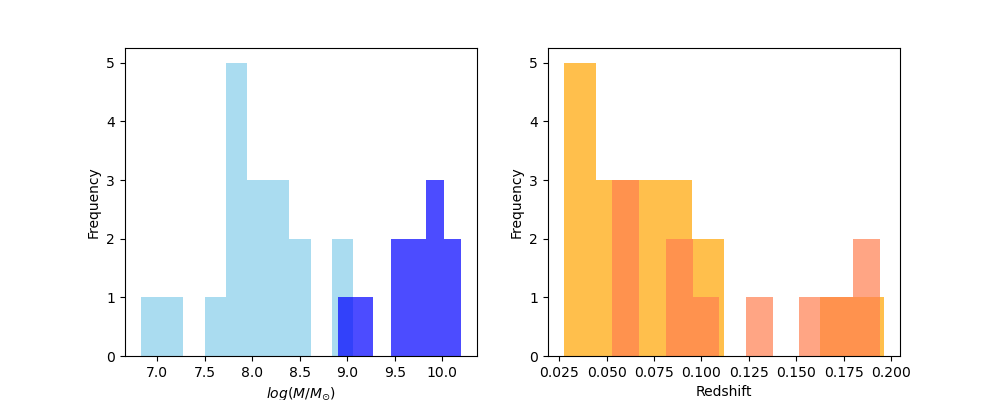

In [8]:
fig, axes = plt.subplots(1,2, figsize=(10, 4))
axes[0].hist(magE['log_M'], color='skyblue', alpha=0.7)
axes[0].hist(magE_2024['mass'], color='blue', bins=7, alpha=0.7)
axes[0].set_xlabel(r'$log(M/M_{\odot}$)')
axes[0].set_ylabel('Frequency')
axes[1].hist(magE['Z'], color='orange', alpha=0.7)
axes[1].hist(magE_2024['z_blue'], color='coral', alpha=0.7)
axes[1].set_xlabel(r'Redshift')
axes[1].set_ylabel('Frequency')
plt.show()

## Compare CECILIA VS MAGE

In [9]:
def steidel(x):
    return 0.66 / (x - 0.31) + 1.14 -0.05

def kewley(x):
    return 0.61 / (x - 0.47) + 1.19

In [10]:
A = ~((cecilia['FO3N'][:, 1] == 0.) | (cecilia['FO3N'][:, 1] == 99.0))
B = ~((cecilia['FN2'][:, 1] == 0.) | (cecilia['FN2'][:, 1] == 99.0))
C = ~((cecilia['FHA'] == 0.) | (cecilia['FHA'] == 99.0))
D = ~((cecilia['FHB'] == 0.) | (cecilia['FHB'] == 99.0))
mask_ceci = (A & B & C & D)

In [11]:
cecilia = cecilia[mask_ceci]

In [12]:
mage_mass = magE['log_M']
mos_mass = cecilia['LMSTAR']
mask1 = (mos_mass == 0.0) | (mos_mass == 99.0)
mask = mask1
mos_mass1 = mos_mass[~mask]
magE24_mass = magE_2024['mass']

# Normalize color mapping based on mass ranges
combined_min_mass = min(np.min(mage_mass), np.min(mos_mass1), np.min(magE24_mass))
combined_max_mass = max(np.max(mage_mass), np.max(mos_mass1), np.max(magE24_mass))
norm = plt.Normalize(vmin=combined_min_mass, vmax=combined_max_mass)
cmap = cm.plasma


In [13]:
cecilia[mask1]['LABEL', 'LMSTAR']


LABEL,LMSTAR
bytes6,float64
RK120,0.0
BX274,0.0
BX628,0.0
fC23,0.0
NB2571,99.0
fBM40,0.0


In [14]:
plt.rcParams["font.family"] = "Serif"

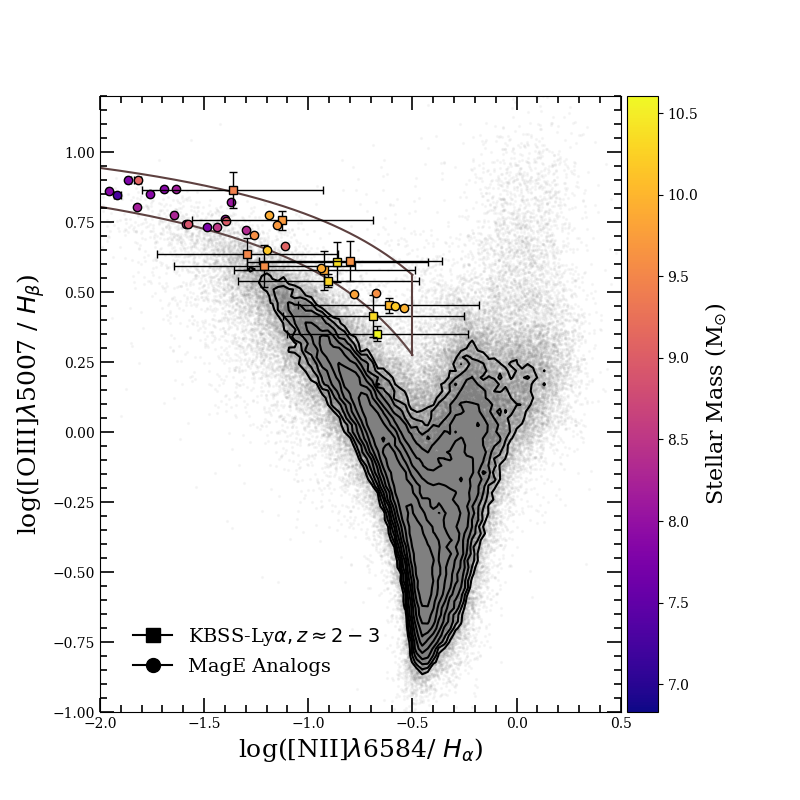

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
contour = True
compare= False
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['N2_S'], SDSS_tab['R3_S'], bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)

    ax.scatter(SDSS_tab['N2_S'], SDSS_tab['R3_S'], alpha=0.05, s=2, c='grey')
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0],
                                           yedges[-1]],
               colors='black')

if compare is True:
    ax.scatter(sdss_bpt['N2_S'], sdss_bpt['R3_S'],
                s=2, color='#e2532f', alpha=0.4, label='SDSS')

# Plot each data point individually with color and error bars for MagE data
for s2, r3, s2_err, r3_err, mass in zip(magE.N2.values, magE.R3.values, magE.N2_err.values, magE.R3_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k',
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color,markersize=6,zorder=2, mec='k')


# Plot each data point individually for MOSFIRE data with 'x' marker
for s2, r3, s2_err, r3_err, mass in zip(cecilia['N2'][~mask], cecilia['R3'][~mask], cecilia['N2_ERR'][~mask], cecilia['R3_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6,zorder=2, mec='k')

color = cmap(norm(8))
s2= -1.43
s2_err=0.2
r3=0.82
r3_err=0.05

# ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
#             elinewidth=1, ms=0, capsize=3,xuplims=True)
# ax.plot(s2, r3, '*', color=color, markersize=11,zorder=2, mec='k')


for s2, r3, s2_err, r3_err, mass in zip(magE_2024['N2'], magE_2024['R3'], magE_2024['N2_ERR'], magE_2024['R3_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k',
                elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6,zorder=2, mec='k')

# Create color bar for stellar mass
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'Stellar Mass (M$_{\odot}$)', fontsize=16)

x = np.linspace(-2.5, -0.5, 1900)
ax.plot(x, steidel(x), color='#5E4140', zorder=-1)
ax.plot(x, kewley(x), color='#5E4140', zorder=-1)
ax.plot((-0.5, -0.5), (np.min(kewley(x)), np.min(steidel(x))), color='#5E4140')

ax.set_ylim(-1., 1.2)
ax.set_xlim(-2., 0.5)
ax.set_xlabel(r'log([NII]$\lambda$6584/ $H_{\alpha}$)', size=18)
ax.set_ylabel(r'log([OIII]$\lambda$5007 / $H_{\beta}$)', size=18)
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()

# proxy_mosfire = plt.plot([1], [0], marker='s', color='black', ms=5, label='KBSS')
proxy_lae = plt.plot([1], [0], marker='s', color='black', ms=5, label=r'KBSS-Ly$\alpha, z \approx 2-3$')
proxy_magE = plt.plot([1], [0], marker='^', color='black', ms=5, ls=None)
proxy_magE24 = plt.plot([1], [0], marker='o', color='black', ms=5, label='MagE Analogs')

# ax.set_xlim(xlim)
# ax.set_ylim(ylim)

# ax.legend(handles=[proxy_mosfire, proxy_lae, proxy_magE, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.03, 0.03))
ax.legend(markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.03, 0.03),fontsize=14)

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
# plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_N2.pdf', format='pdf')
plt.show()

In [20]:
sdss_mage = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/paper/mage.txt')

In [21]:
from uncertainties import unumpy as unp
O3 = unp.uarray(sdss_mage['O3'].values, sdss_mage['O3_ERR'].values)
N2 = unp.uarray(sdss_mage['N2'].values, sdss_mage['N2_ERR'].values)
HA = unp.uarray(sdss_mage['HA'].values, sdss_mage['HA_ERR'].values)
HB = unp.uarray(sdss_mage['HB'].values, sdss_mage['HB_ERR'].values)

sdss_mage['O3_HB'] = unp.log10(O3 / HB)
sdss_mage['N2_HA'] = unp.log10(N2 / HA)

In [22]:
sdss_mage

,ID,RA,DEC,O3,O3_ERR,HB,HB_ERR,N2,N2_ERR,HA,HA_ERR,O3_HB,N2_HA
0,J2204+0058,331.113126,0.971704,697.5059,5.531796,168.04390,2.960766,71.35751,11.312080,504.7038,6.034044,0.618+/-0.008,-0.85+/-0.07
1,J2258+0056,344.640597,0.941829,631.1217,6.872253,126.63540,2.561989,19.87024,1.228296,391.1720,4.503589,0.698+/-0.010,-1.294+/-0.027
2,J2336-0042,354.052627,-0.712240,667.3795,8.692021,170.27830,3.835635,62.04980,1.849414,562.4700,6.767969,0.593+/-0.011,-0.957+/-0.014
3,J0020+0030,5.090052,0.505978,781.8654,5.275414,243.00650,2.851100,184.78290,2.577540,877.0142,4.356181,0.508+/-0.006,-0.676+/-0.006
4,J0203+0035,30.866851,0.586199,220.6937,4.570529,85.34006,2.692020,68.13238,3.123924,292.8135,3.923118,0.413+/-0.016,-0.633+/-0.021
5,J0243+0111,40.979881,1.196914,928.1254,8.762062,178.67480,3.014141,35.53469,1.403489,588.6031,5.480621,0.716+/-0.008,-1.219+/-0.018
6,J0328+0031,52.222260,0.517824,2111.6680,13.930600,674.97280,6.329804,390.27200,3.506021,2383.9690,14.761010,0.495+/-0.005,-0.786+/-0.005
7,J0333+0017,53.330010,0.292061,1544.8860,12.868200,296.36340,3.844016,54.68406,4.241615,1025.6650,7.958936,0.717+/-0.007,-1.273+/-0.034
8,J0404-0538,61.045494,-5.635819,237.5706,3.034441,88.19966,2.044943,73.46783,1.538976,326.0974,2.867663,0.430+/-0.011,-0.647+/-0.010


In [23]:
sdss_mage['O3_HB'].std_dev

AttributeError: 'Series' object has no attribute 'std_dev'

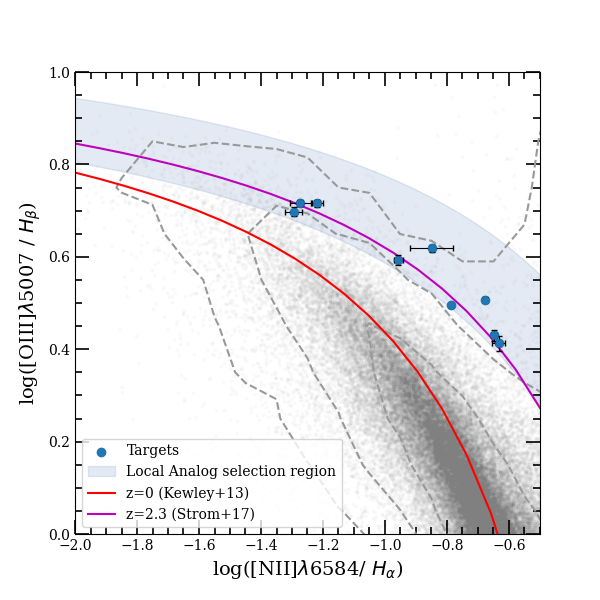

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
contour = True
compare= True
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['N2_S'], SDSS_tab['R3_S'], bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    # ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0],
    #                                        yedges[-1]],
    #            colors='#5E4140')

    ax.scatter(SDSS_tab['N2_S'], SDSS_tab['R3_S'], alpha=0.03, s=3, c='grey')
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])
H = np.load('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/paper/contours.npy')
plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')

# if compare is True:
#     ax.scatter(sdss_bpt['N2_S'], sdss_bpt['R3_S'],
#                 s=8, color='grey', alpha=0.4)

# ax.plot(FN2, FR3, ms=5, ls='None', color='#012CC8', label='MOSFIRE', marker='x')
# ax.errorbar(cecilia['N2'], cecilia['R3'], xerr=cecilia['N2_ERR'], yerr=cecilia['R3_ERR'],
#             fmt='o', c='red', ecolor='black',
#              elinewidth=1, ms=3, capsize=3, label='KBSS-Ly$\\alpha$')

# ax.scatter(magE.N2, magE.R3, s=8, color='red')
# ax.errorbar(magE.N2, magE.R3, xerr=magE.N2_err, yerr=magE.N2_err, fmt='x',
#             c='red', ecolor='black',  elinewidth=2,
#             ms=3, capsize=3)

# ax.scatter(magE_2024['N2'], magE_2024['R3'], color='red', s=8, label='Targets')
# ax.errorbar(magE_2024['N2'], magE_2024['R3'], xerr=magE_2024['N2_ERR'], yerr=magE_2024['R3_ERR'],
#             fmt='o', c='red', ecolor='black',
#              elinewidth=1, ms=3, capsize=3, label='targets')
x = unp.nominal_values(sdss_mage['N2_HA'])
y = unp.nominal_values(sdss_mage['O3_HB'])

xerr = unp.std_devs(sdss_mage['N2_HA'])
yerr = unp.std_devs(sdss_mage['O3_HB'])

ax.scatter(x, y, label='Targets')
ax.errorbar(x, y,
            xerr=xerr, yerr=yerr,
            fmt='o', ecolor='black',
            elinewidth=0.8, capsize=2,
            ms=5, zorder=5)


x_ = np.linspace(-2.5, -0.5, 1900)
steidel_values = steidel(x_)
kewley_values = kewley(x_)
ax.fill_between(x_, kewley_values, steidel_values, alpha=0.15, color='#4C72B0',
                label='Local Analog selection region' , edgecolor='#4C72B0', linewidth=1)


ax.set_ylim(-1., 1.)
ax.set_xlim(-2., 0.5)
ax.set_xlabel(r'log([NII]$\lambda$6584/ $H_{\alpha}$)', size=14)
ax.set_ylabel(r'log([OIII]$\lambda$5007 / $H_{\beta}$)', size=14)

# plt.legend(markerscale=8, frameon=False, bbox_to_anchor=(0.03, 0.03),
#            loc='lower left', borderaxespad=0, fontsize=16)
# plt.legend(markerscale=5, frameon=False, bbox_to_anchor=(0.03, 0.03),
#            loc='lower left', borderaxespad=0, fontsize=16)

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
# plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_N2_v2.png',
#             format='png', bbox_inches='tight')


x_boundaries = np.linspace(-2, -0.5, 20)

# y_boundaries_lo = min_O3Hb(x_boundaries)
y_boundaries_lo = 1.14 + 0.66 / (x_boundaries - 0.31)


z0 = 1.1 + 0.61 / (x_boundaries + 0.08) #Kewley +2013
z23 = 1.13 + 0.67 / (x_boundaries - 0.33)
z23_strom = 1.12 + 0.61 / (x_boundaries - 0.22) # Strom+ 2017

plt.plot(x_boundaries, z0, 'r-', label='z=0 (Kewley+13)')
# plt.plot(x_boundaries, z23, 'g-', label='z=2.3')
plt.plot(x_boundaries, z23_strom, 'm-', label='z=2.3 (Strom+17)')
plt.ylim(0, 1)
plt.xlim(-2, -0.5)
plt.legend()
plt.show()
plt.savefig('BPT_selection.pdf', format='pdf')

In [25]:
docPath = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2'
magePath = docPath + '/lines/'
el_cat = pd.read_csv(magePath+'magE2024_master_EWcorr.csv')

O16300 = upy.uarray(el_cat['O1_6300_flux'].to_numpy(),
                     el_cat['O1_6300_fluxerr'].to_numpy())

Ha = upy.uarray(el_cat['H_alpha_flux'].to_numpy(),
                el_cat['H_alpha_fluxerr'].to_numpy())

O1 = upy.log10(O16300 / Ha)


In [26]:
H, xedges, yedges = np.histogram2d(SDSS_tab['S2_S'][~np.isnan(SDSS_tab['S2_S'])],
                                   SDSS_tab['R3_S'][~np.isnan(SDSS_tab['S2_S'])], bins=150)

ValueError: autodetected range of [-inf, 9.3175745] is not finite

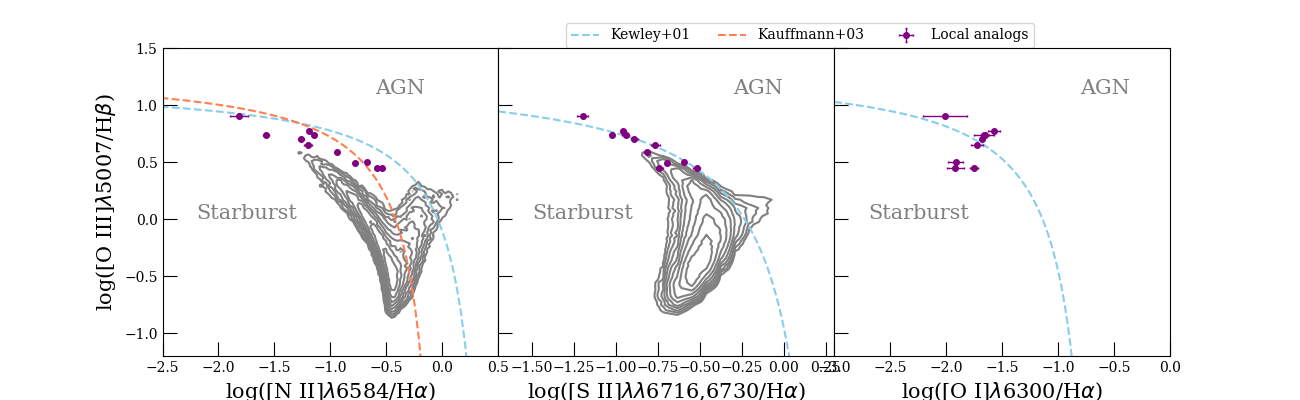

In [27]:
def kewley2001(bpt_x, mode='N2'):
    if mode == 'N2':
        den = (bpt_x - 0.47)
        bpt_y = (0.61 / den) + 1.19

    elif mode == 'S2':
        den = (bpt_x - 0.32)
        bpt_y = (0.72 / den) + 1.3

    elif mode == 'O1':
        den = (bpt_x + 0.59)
        bpt_y = (0.73 / den) + 1.33

    return bpt_y

def kauffmann2003(bpt_x):
    den = (bpt_x - 0.05)
    return (0.61 / den) + 1.3

fig, axs = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(13, 4)
fig.subplots_adjust(wspace=0)

# Plotting SDSS galaxies
H, xedges, yedges = np.histogram2d(SDSS_tab['N2_S'], SDSS_tab['R3_S'], bins=150)
H_flat = H.flatten()
H_sorted = np.sort(H_flat)[::-1]
H_cumsum = np.cumsum(H_sorted)
H_cumsum_normalized = H_cumsum / H_cumsum[-1]
level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
axs[0].contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0],
                                        yedges[-1]],
               colors='grey')

mask = (~np.isnan(SDSS_tab['S2_S'])) & (~np.isinf(SDSS_tab['S2_S']))
H, xedges, yedges = np.histogram2d(SDSS_tab['S2_S'][mask],
                                   SDSS_tab['R3_S'][mask], bins=150)
H_flat = H.flatten()
H_sorted = np.sort(H_flat)[::-1]
H_cumsum = np.cumsum(H_sorted)
H_cumsum_normalized = H_cumsum / H_cumsum[-1]
level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
axs[1].contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0],
                                        yedges[-1]],
               colors='grey')

R1_S = SDSS_tab['OI_6300_FLUX']/SDSS_tab['H_ALPHA_FLUX']
H, xedges, yedges = np.histogram2d(R1_S, SDSS_tab['R3_S'], bins=150)
H_flat = H.flatten()
H_sorted = np.sort(H_flat)[::-1]
H_cumsum = np.cumsum(H_sorted)
H_cumsum_normalized = H_cumsum / H_cumsum[-1]
level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
axs[2].contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0],
                                        yedges[-1]],
               colors='grey')
axs[2].scatter(upy.nominal_values(O1), magE_2024['R3'][:-2], s=0.5, color='lightgray', alpha=0.2)

# Local analogs
axs[0].errorbar(magE_2024['N2'], magE_2024['R3'],
                xerr=5*(magE_2024['N2_ERR']), yerr=5*(magE_2024['R3_ERR']),
                elinewidth=1, capsize=1,
                fmt='o', color='purple', ms=4, label='Local analogs', zorder=5)
axs[1].errorbar(magE_2024['S2'], magE_2024['R3'],
                xerr=5*(magE_2024['S2_ERR']), yerr=5*(magE_2024['R3_ERR']),
                elinewidth=1, capsize=1,
                fmt='o', color='purple', ms=4, label='Local analogs', zorder=5)
axs[2].errorbar(upy.nominal_values(O1), magE_2024['R3'][:-2],
                xerr=5*(upy.std_devs(O1)), yerr=5*(magE_2024['R3_ERR'][:-2]),
                elinewidth=1, capsize=1,
                fmt='o', color='purple', ms=4, label='Local analogs', zorder=5)


# Demarcations
ha_nii = np.linspace(-3.5, 0.4, 100)
ha_nii_alt = np.linspace(-3.5, 0, 100)
ha_sii = np.linspace(-1.7, 0.3, 100)
ha_oi = np.linspace(-3, -0.7, 100)
axs[0].plot(ha_nii, kewley2001(ha_nii, 'N2'), ls='--', color='skyblue', label='Kewley+01')
axs[0].plot(ha_nii_alt, kauffmann2003(ha_nii_alt), ls='--', color='coral', label='Kauffmann+03')
axs[1].plot(ha_sii, kewley2001(ha_sii, 'S2'), ls='--', color='skyblue', label='Kewley+01')
axs[2].plot(ha_oi, kewley2001(ha_oi, 'O1'), ls='--', color='skyblue', label='Kewley+01')

# Labels
axs[0].set_ylabel(r'log([O III]$\lambda$5007/H$\beta$)', fontsize=15)
axs[0].set_xlabel(r'log([N II]$\lambda$6584/H$\alpha$)', fontsize=15)

axs[1].set_xlabel(r'log([S II]$\lambda\lambda$6716,6730/H$\alpha$)', fontsize=15)
axs[2].set_xlabel(r'log([O I]$\lambda$6300/H$\alpha$)', fontsize=15)

# Limits
axs[0].set_xlim(-2.5, 0.5)
axs[0].set_ylim(-1.2, 1.5)
axs[1].set_xlim(-1.7, 0.3)
axs[2].set_xlim(-3, 0)

# Legends
axs[0].legend(ncols=3, loc = (1.2, 1.0))

# Regions
axs[0].text(-0.6, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[0].text(-2.2, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[1].text(-0.3, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[1].text(-1.5, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[2].text(-0.8, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[2].text(-2.7, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[0].tick_params(axis='both', direction='in', length=10)
axs[1].tick_params(axis='both', direction='in', length=10)
axs[2].tick_params(axis='both', direction='in', length=10)

#fig.savefig(magePath+'analysis/chapter5/bpt_diagnosis.jpg', bbox_inches='tight', dpi=300)

In [28]:
a = SDSS_tab['OI_6300_FLUX'].values/SDSS_tab['H_ALPHA_FLUX'].values
a[a<1]


array([0.03493423, 0.03409476, 0.03292307, ..., 0.03438052, 0.01650666,
       0.03482593], shape=(255622,))

In [29]:
SDSS_tab['R3_S']

0        -0.135620
1        -0.532670
2        -0.240209
3        -0.052972
4        -0.180501
            ...   
255733    0.080575
255734    0.477810
255735    0.162450
255736   -0.552844
255737   -0.306606
Name: R3_S, Length: 255738, dtype: float64

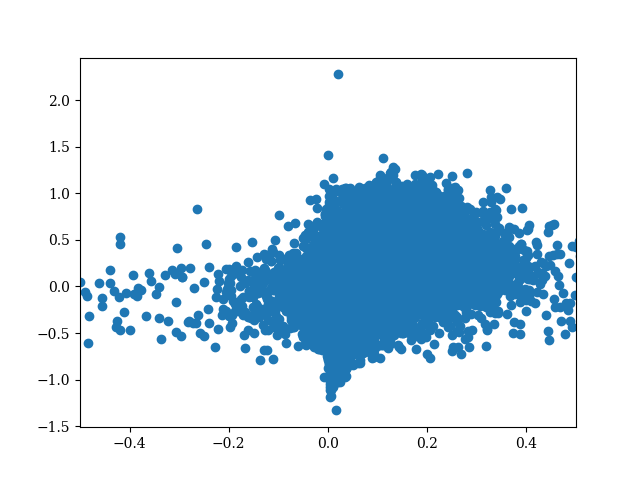

In [30]:
plt.figure()
plt.scatter(SDSS_tab['OI_6300_FLUX']/SDSS_tab['H_ALPHA_FLUX'],SDSS_tab['R3_S'] )
plt.xlim(-0.5, 0.5)
plt.show()

In [221]:
# Define stellar masses for color scaling
mage_mass = magE['log_M']
mos_mass = cecilia['LMSTAR']
mask1 = (mos_mass == 0.0) | (mos_mass == 99.0)
ceci_mask = (np.isinf(cecilia['S2'].filled(np.nan))) | (np.isinf(cecilia['R3'].filled(np.nan)))
mask = ceci_mask | mask1
mos_mass1 = mos_mass[~mask]
magE24_mass = magE_2024['mass']

# Normalize color mapping based on mass ranges
combined_min_mass = min(np.min(mage_mass), np.min(mos_mass1), np.min(magE24_mass))
combined_max_mass = max(np.max(mage_mass), np.max(mos_mass1), np.max(magE24_mass))
norm = plt.Normalize(vmin=combined_min_mass, vmax=combined_max_mass)
cmap = cm.plasma


/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_35942/260171029.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(markerscale=2, frameon=False, bbox_to_anchor=(0.03, 0.03), loc='lower left', borderaxespad=0)


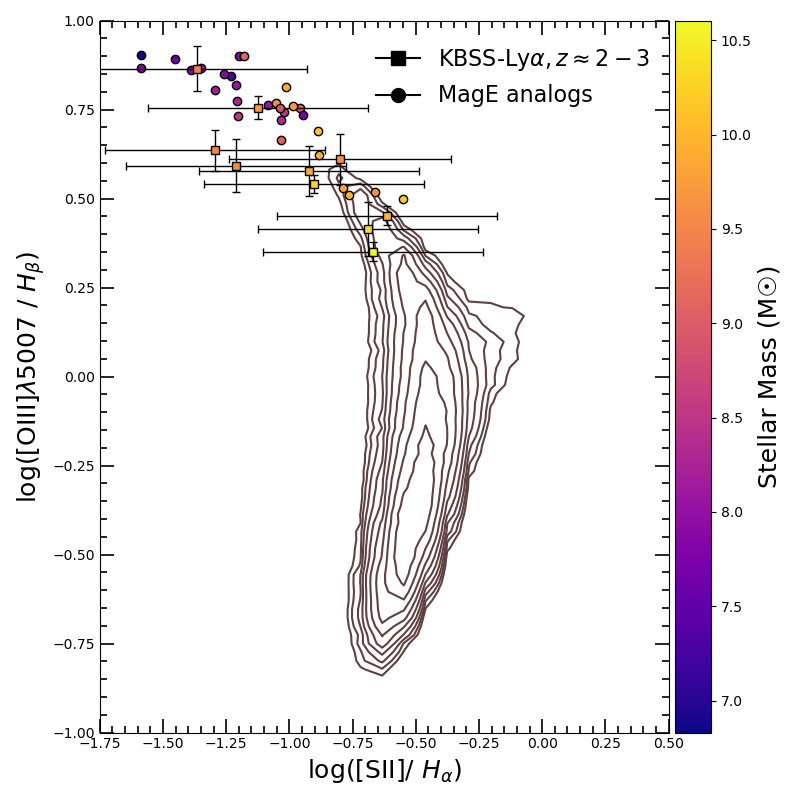

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
contour = True
compare = False

# Mask to filter NaN and infinity values
nan_mask = ~(np.isnan(SDSS_tab['S2_S']) | np.isinf(SDSS_tab['S2_S']))

# Create 2D histogram and contour if enabled
if contour:
    H, xedges, yedges = np.histogram2d(SDSS_tab['S2_S'][nan_mask],
                                       SDSS_tab['R3_S'][nan_mask],
                                       bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], colors='#5E4140')

# SDSS scatter plot if enabled
if compare:
    ax.scatter(sdss_bpt['N2_S'], sdss_bpt['R3_S'], s=0.5, color='#e2532f', alpha=0.4, label='SDSS')


# Plot each data point individually with color and error bars for MagE data
for s2, r3, s2_err, r3_err, mass in zip(magE.S2.values, magE.R3.values, magE.S2_err.values, magE.R3_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6,zorder=2, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(cecilia['N2'][~mask], cecilia['R3'][~mask], cecilia['N2_ERR'][~mask], cecilia['R3_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6,zorder=2, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(magE_2024['S2'], magE_2024['R3'], magE_2024['S2_ERR'], magE_2024['R3_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k',
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6,zorder=2, mec='k')
# Create color bar for stellar mass
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Stellar Mass (M☉)', fontsize=18)  # Set the colorbar label and fontsize

# Set axis limits and labels
ax.set_ylim(-1., 1.)
ax.set_xlim(-1.75, 0.5)
ax.set_xlabel(r'log([SII]/ $H_{\alpha}$)', size=18)
ax.set_ylabel(r'log([OIII]$\lambda$5007 / $H_{\beta}$)', size=18)
plt.legend(markerscale=2, frameon=False, bbox_to_anchor=(0.03, 0.03), loc='lower left', borderaxespad=0)

# Customize ticks
ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

proxy_mosfire = plt.Line2D([0], [0], marker='s', color='black', ms=5, label=r'KBSS-Ly$\alpha, z \approx 2-3$')
proxy_magE24 = plt.Line2D([0], [0], marker='o', color='black', ms=5, label='MagE analogs')

ax.legend(handles=[proxy_mosfire, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.45, 0.85), fontsize=16)

plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_S2.pdf', format='pdf')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_S2.png', format='png')
plt.tight_layout()
plt.show()

In [223]:
mage_mass = magE['log_M']
mos_mass = cecilia['LMSTAR']
mask1 = (mos_mass == 0.0) | (mos_mass == 99.0)
ceci_mask = (np.isinf(cecilia['R23'].filled(np.nan))) | (np.isinf(cecilia['O32'].filled(np.nan)))
mask = ceci_mask | mask1
mos_mass1 = mos_mass[~mask]
magE24_mass = magE_2024['mass']

# Normalize color mapping based on mass ranges
combined_min_mass = min(np.min(mage_mass), np.min(mos_mass1), np.min(magE24_mass))
combined_max_mass = max(np.max(mage_mass), np.max(mos_mass1), np.max(magE24_mass))
norm = plt.Normalize(vmin=combined_min_mass, vmax=combined_max_mass)
cmap = cm.plasma

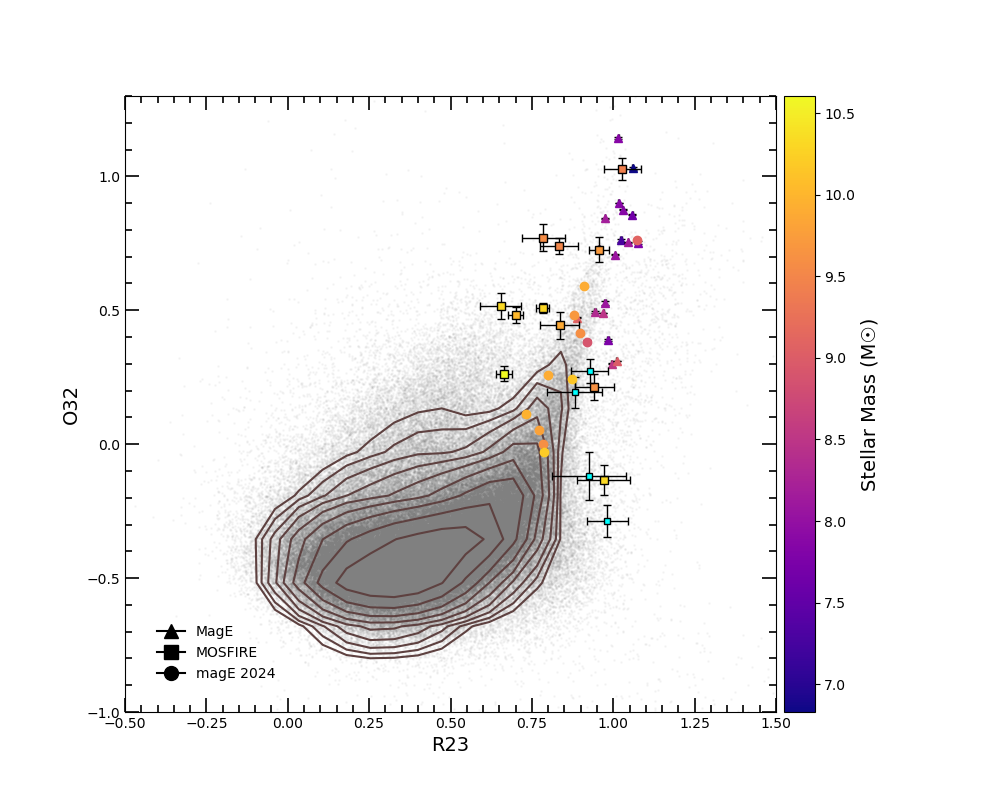

In [224]:
fig, ax = plt.subplots(1, 1, figsize=(10,8))
contour = True
nan_mask = ~( np.isnan(SDSS_tab['R23_S']) | np.isinf(SDSS_tab['R23_S']) |
            np.isnan(SDSS_tab['O32_S']) | np.isinf(SDSS_tab['O32_S']))
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['R23_S'][nan_mask],
                                       SDSS_tab['O32_S'][nan_mask],
                                       bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], colors='#5E4140')
    ax.scatter(SDSS_tab['R23_S'][nan_mask], SDSS_tab['O32_S'][nan_mask],
                alpha=0.05, s=1, c='grey')

for s2, r3, s2_err, r3_err, mass in zip(magE.R23.values, magE.O3O2.values, magE.R23_err.values, magE.O3O2_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='^', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, '^', color=color, markersize=6, zorder=2)

# Plot each data point individually for MOSFIRE data with 'x' marker
for s2, r3, s2_err, r3_err, mass in zip(cecilia['R23'][~mask], cecilia['O32'][~mask], cecilia['R23_ERR'][~mask], cecilia['O32_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6,zorder=2, mec='k')

no_mass = ax.errorbar(cecilia['R23'][mask], cecilia['O32'][mask], xerr=cecilia['R23_ERR'][mask],
            yerr=cecilia['O32_ERR'][mask], fmt='s', c='cyan', ecolor='black',
            ms=4, capsize=3, label='MOSFIRE no mass', elinewidth=1, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(magE_2024['R23'], magE_2024['O3O2'], magE_2024['R23_ERR'], magE_2024['O3O2_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k',
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6,zorder=2, ls=None)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, label='Stellar Mass (M☉)', pad=0.01)
cbar.set_label('Stellar Mass (M☉)', size=14)

ax.set_ylim(-1., 1.3)
ax.set_xlim(-0.5, 1.5)
ax.set_xlabel(r'R23', size=14)
ax.set_ylabel(r'O32', size=14)

proxy_magE = plt.Line2D([0], [0], marker='^', color='black', ms=5, label='MagE')
proxy_mosfire = plt.Line2D([0], [0], marker='s', color='black', ms=5, label='MOSFIRE')
proxy_magE24 = plt.Line2D([0], [0], marker='o', color='black', ms=5, label='magE 2024')

ax.legend(handles=[proxy_magE, proxy_mosfire, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.03, 0.03))

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_R23_O32.pdf', format='pdf')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_R23_O32.png', format='png')

plt.show()

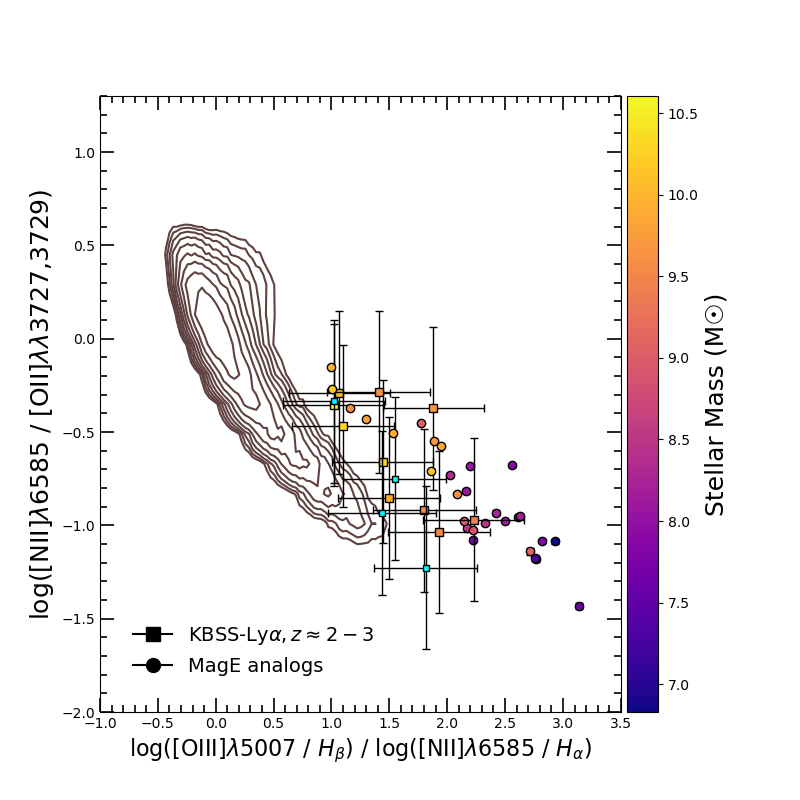

In [249]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
contour = True
nan_mask = ~( np.isnan(SDSS_tab['O3N2_S']) | np.isinf(SDSS_tab['O3N2_S']) |
            np.isnan(SDSS_tab['N2O2_S']) | np.isinf(SDSS_tab['N2O2_S']))
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['O3N2_S'][nan_mask],
                                       SDSS_tab['N2O2_S'][nan_mask],
                                       bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], colors='#5E4140')
    # ax.scatter(SDSS_tab['O3N2_S'][nan_mask], SDSS_tab['N2O2_S'][nan_mask],
    #             alpha=0.05, s=1, c='grey')


for s2, r3, s2_err, r3_err, mass in zip(magE.O3N2.values, magE.N2O2.values, magE.O3N2_err.values, magE.N2O2_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6,zorder=2, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(cecilia['O3N2'][~mask], cecilia['N202'][~mask], cecilia['O3N2_ERR'][~mask], cecilia['N2O2_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6, zorder=2, mec='k')

ax.errorbar(cecilia['O3N2'][mask], cecilia['N202'][mask], xerr=cecilia['O3N2_ERR'][mask],
            yerr=cecilia['N2O2_ERR'][mask], fmt='s', c='cyan', ecolor='black',
    ms=5, capsize=3, label='MOSFIRE no mass', elinewidth=1, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(magE_2024['O3N2'], magE_2024['N2O2'], magE_2024['O3N2_ERR'], magE_2024['N2O2_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6, zorder=2, mec='k')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
clb = plt.colorbar(sm, ax=ax, pad=0.01)
clb.set_label('Stellar Mass (M☉)', size=18)
ax.set_ylim(-2., 1.3)
ax.set_xlim(-1, 3.5)
ax.set_xlabel(r'log([OIII]$\lambda$5007 / $H_{\beta}$) / log([NII]$\lambda$6585 / $H_{\alpha}$)', size=16)
ax.set_ylabel(r'log([NII]$\lambda$6585 / [OII]$\lambda\lambda$3727,3729)', size=18)


# proxy_magE = plt.Line2D([0], [0], marker='^', color='black', ms=5, label='MagE')
proxy_mosfire = plt.Line2D([0], [0], marker='s', color='black', ms=5, label=r'KBSS-Ly$\alpha, z \approx 2-3$')
proxy_magE24 = plt.Line2D([0], [0], marker='o', color='black', ms=5, label='MagE analogs')

ax.legend(handles=[proxy_mosfire, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.03, 0.03), fontsize=14)

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_O3N2_N2O2.pdf', format='pdf')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_O3N2_N2O2.png', format='png')
plt.show()

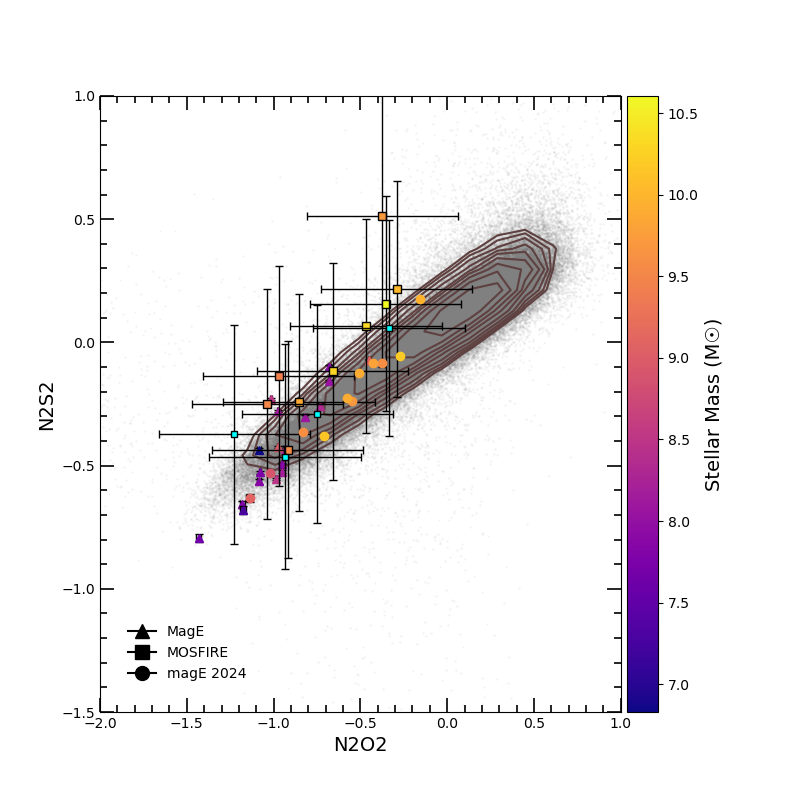

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
contour = True
nan_mask = ~( np.isnan(SDSS_tab['N2S2_S']) | np.isinf(SDSS_tab['N2S2_S']) |
            np.isnan(SDSS_tab['N2O2_S']) | np.isinf(SDSS_tab['N2O2_S']))
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['N2O2_S'][nan_mask],
                                       SDSS_tab['N2S2_S'][nan_mask],
                                       bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], colors='#5E4140')
    ax.scatter(SDSS_tab['N2O2_S'][nan_mask], SDSS_tab['N2S2_S'][nan_mask],
                alpha=0.05, s=1, c='grey')


mage_mass = magE['log_M']
mos_mass = cecilia['LMSTAR']
mask1 = (mos_mass == 0.0) | (mos_mass == 99.0)
ceci_mask = (np.isinf(cecilia['N202'].filled(np.nan))) | (np.isinf(cecilia['N2S2'].filled(np.nan)))
mask = ceci_mask | mask1
mos_mass1 = mos_mass[~mask]


# Normalize color mapping based on mass ranges
combined_min_mass = min(np.min(mage_mass), np.min(mos_mass1), np.min(magE24_mass))
combined_max_mass = max(np.max(mage_mass), np.max(mos_mass1), np.max(magE24_mass))
norm = plt.Normalize(vmin=combined_min_mass, vmax=combined_max_mass)
cmap = cm.plasma

# Plot each data point individually with color and error bars for MagE data
for s2, r3, s2_err, r3_err, mass in zip(magE.N2O2.values, magE.N2S2.values, magE.N2O2_err.values, magE.N2S2_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='^', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, '^', color=color, markersize=6, zorder=2)

# Plot each data point individually for MOSFIRE data with 'x' marker
for s2, r3, s2_err, r3_err, mass in zip(cecilia['N202'][~mask], cecilia['N2S2'][~mask], cecilia['N2O2_ERR'][~mask], cecilia['N2S2_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6, zorder=2, mec='k')

ax.errorbar(cecilia['N202'][mask], cecilia['N2S2'][mask], xerr=cecilia['N2O2_ERR'][mask],
            yerr=cecilia['N2S2_ERR'][mask], fmt='s', c='cyan', ecolor='black',
            ms=4, capsize=3, label='MOSFIRE no mass', elinewidth=1, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(magE_2024['N2O2'], magE_2024['N2S2'], magE_2024['N2O2_ERR'], magE_2024['N2S2_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6, zorder=2)

# Create color bar for stellar mass
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
clr = plt.colorbar(sm, ax=ax, pad=0.01)
clr.set_label('Stellar Mass (M☉)', size=14)
# ax.set_ylim(-1., 1.)
# ax.set_xlim(-2, 1)
ax.set_xlabel(r'N2O2', size=14)
ax.set_ylabel(r'N2S2', size=14)
ax.set_xlim(-2.0, 1.0)
ax.set_ylim(-1.5, 1.0)

proxy_magE = plt.Line2D([0], [0], marker='^', color='black', ms=5, label='MagE')
proxy_mosfire = plt.Line2D([0], [0], marker='s', color='black', ms=5, label='MOSFIRE')
proxy_magE24 = plt.Line2D([0], [0], marker='o', color='black', ms=5, label='magE 2024')

ax.legend(handles=[proxy_magE, proxy_mosfire, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.03, 0.03))

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')


plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_N2O2_N2S2.pdf', format='pdf')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_N202_N2S2.png', format='png')
plt.show()

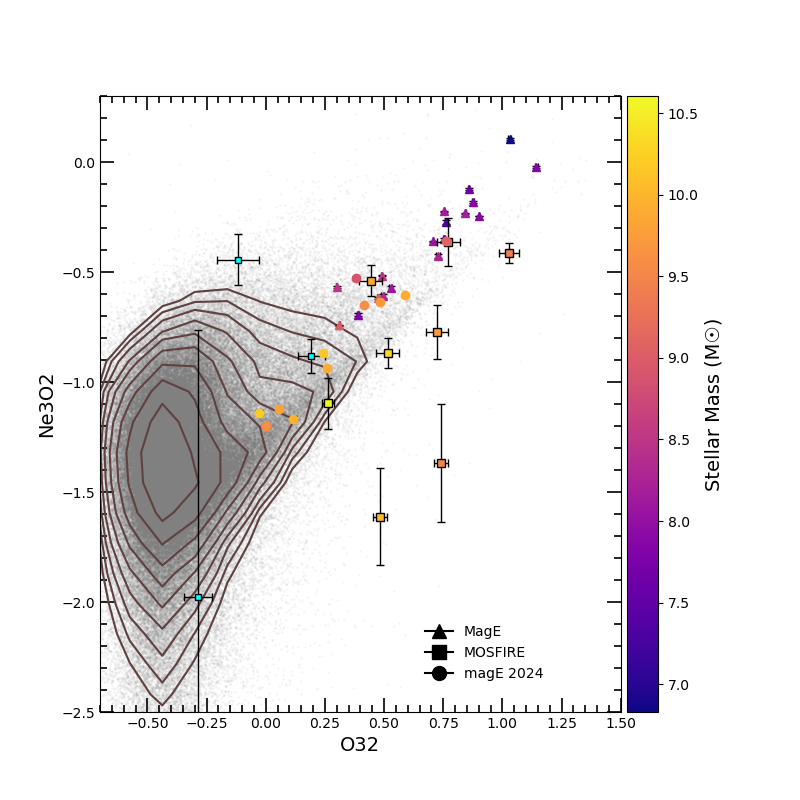

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
contour = True
nan_mask = ~( np.isnan(SDSS_tab['O32_S']) | np.isinf(SDSS_tab['O32_S']) |
            np.isnan(SDSS_tab['Ne3O2_S']) | np.isinf(SDSS_tab['Ne3O2_S']))
if contour is True:
    H, xedges, yedges = np.histogram2d(SDSS_tab['O32_S'][nan_mask],
                                       SDSS_tab['Ne3O2_S'][nan_mask],
                                       bins=150)
    H_flat = H.flatten()
    H_sorted = np.sort(H_flat)[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum_normalized = H_cumsum / H_cumsum[-1]
    level_90 = H_sorted[np.searchsorted(H_cumsum_normalized, 0.9)]
    levels = np.logspace(np.log10(level_90), np.log10(H.max()), 10)
    ax.contour(H.T, levels=levels, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], colors='#5E4140')
    ax.scatter(SDSS_tab['O32_S'][nan_mask], SDSS_tab['Ne3O2_S'][nan_mask],
                alpha=0.05, s=1, c='grey')


mage_mass = magE['log_M']
mos_mass = cecilia['LMSTAR']
mask1 = (mos_mass == 0.0) | (mos_mass == 99.0)
ceci_mask = (np.isinf(cecilia['O32'].filled(np.nan))) | (np.isinf(cecilia['Ne3O2'].filled(np.nan)))
mask = ceci_mask | mask1
mos_mass1 = mos_mass[~mask]

# Normalize color mapping based on mass ranges
combined_min_mass = min(np.min(mage_mass), np.min(mos_mass1), np.min(magE24_mass))
combined_max_mass = max(np.max(mage_mass), np.max(mos_mass1), np.max(magE24_mass))
norm = plt.Normalize(vmin=combined_min_mass, vmax=combined_max_mass)
cmap = cm.plasma

# Plot each data point individually with color and error bars for MagE data
for s2, r3, s2_err, r3_err, mass in zip(magE.O3O2.values, magE.Ne3O2.values, magE.O3O2_err.values, magE.Ne3O2_err.values, mage_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='^', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, '^', color=color, markersize=6, zorder=2)

# Plot each data point individually for MOSFIRE data with 'x' marker
for s2, r3, s2_err, r3_err, mass in zip(cecilia['O32'][~mask], cecilia['Ne3O2'][~mask], cecilia['O32_ERR'][~mask], cecilia['Ne3O2_ERR'][~mask], mos_mass1):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='s', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 's', color=color, markersize=6, zorder=2, mec='k')

ax.errorbar(cecilia['O32'][mask], cecilia['Ne3O2'][mask], xerr=cecilia['O32_ERR'][mask],
            yerr=cecilia['Ne3O2_ERR'][mask], fmt='s', c='cyan', ecolor='black',
            ms=4, capsize=3, label='MOSFIRE no mass', elinewidth=1, mec='k')

for s2, r3, s2_err, r3_err, mass in zip(magE_2024['O3O2'], magE_2024['Ne3O2'], magE_2024['O3O2_ERR'], magE_2024['Ne3O2_ERR'], magE24_mass):
    color = cmap(norm(mass))
    ax.errorbar(s2, r3, yerr=r3_err, xerr=s2_err, fmt='o', c='k', #c=color,
             elinewidth=1, ms=0, capsize=3)
    ax.plot(s2, r3, 'o', color=color, markersize=6, zorder=2)

# Create color bar for stellar mass
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
clb = plt.colorbar(sm, ax=ax, pad=0.01)
clb.set_label('Stellar Mass (M☉)', size=14)

ax.set_ylim(-2.5, 0.3)
ax.set_xlim(-0.7, 1.5)
ax.set_xlabel(r'O32', size=14)
ax.set_ylabel(r'Ne3O2',size=14)

proxy_magE = plt.Line2D([0], [0], marker='^', color='black', ms=5, label='MagE')
proxy_mosfire = plt.Line2D([0], [0], marker='s', color='black', ms=5, label='MOSFIRE')
proxy_magE24 = plt.Line2D([0], [0], marker='o', color='black', ms=5, label='magE 2024')

ax.legend(handles=[proxy_magE, proxy_mosfire, proxy_magE24], markerscale=2, frameon=False, loc='lower left', bbox_to_anchor=(0.6, 0.03))

ax.minorticks_on()
ax.tick_params(which='major', length=10, width=1.2, direction='in')
ax.tick_params(which='minor', length=5, width=1.2, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_O32_Ne3O2.pdf', format='pdf')
plt.savefig('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/images/BPT/BPT_O3N_Ne3O2.png', format='png')
plt.show()

In [81]:
data = np.loadtxt('/Users/javieratoro/Desktop/thesis/rogers2025_jwst_abun_te_lit.dat')
columns= ['12+log(O/H)', '12+log(O/H)_err', 'T[O II]', 'T[O II]_err', 'flag_T[O II]', 'T[O III]', 'T[O III]_err', 'flag_T[O III]', 'T[S III', 'T[S III]_err', 'flag_T[S III]']

#  These aren't organized by literature source,
#  but come from the following: Welch+2024, Welch+2025, Morishita+2024,
#  Stanton+2025, Arellano-Cordova+2025, Sanders+2024, Cataldi+2025, Sanders+2025.


In [78]:
data.shape

(85, 11)

In [82]:
len(columns)

11